In [1]:
import pandas as pd
import os

# Load the primary files to inspect them
matches_df = pd.read_csv('../data/matches.csv')
batting_df = pd.read_csv('../data/batting_scorecard.csv')

print("\n--- Matches Dataset Info ---")
print(matches_df.info())

print("\n--- Batting Dataset Info ---")
print(batting_df.info())


--- Matches Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   match_id       9 non-null      int64
 1   date           9 non-null      str  
 2   team1          9 non-null      str  
 3   team2          9 non-null      str  
 4   venue          9 non-null      str  
 5   toss_winner    9 non-null      str  
 6   toss_decision  9 non-null      str  
 7   winner         9 non-null      str  
 8   result         9 non-null      str  
 9   result_margin  9 non-null      int64
dtypes: int64(2), str(8)
memory usage: 852.0 bytes
None

--- Batting Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   match_id     9 non-null      int64  
 1   innings      9 non-null      int64  
 2   player       9 non-null     

In [2]:
# 1. Analyze Match Outcomes
win_counts = matches_df['winner'].value_counts()
print("--- Win Distribution ---")
print(win_counts)

# 2. Basic Batting Stats
# Note: Check your batting_df head to see if we have 'runs' or 'balls_faced'
print("\n--- First 5 rows of Batting Data ---")
print(batting_df.head())

--- Win Distribution ---
winner
RCB    6
RR     1
DC     1
GT     1
Name: count, dtype: int64

--- First 5 rows of Batting Data ---
   match_id  innings         player  runs  balls  fours  sixes  strike_rate  \
0         1        2    Virat Kohli    69     38      5      5       181.58   
1         2        1      Tim David    70     25      3      8       280.00   
2         3        1  Rajat Patidar    63     40      4      4       157.50   
3         4        1      Phil Salt    78     36      6      6       216.67   
4         5        2    Virat Kohli    49     34      6      1       144.12   

  dismissal  
0   not out  
1   not out  
2       out  
3       out  
4       out  


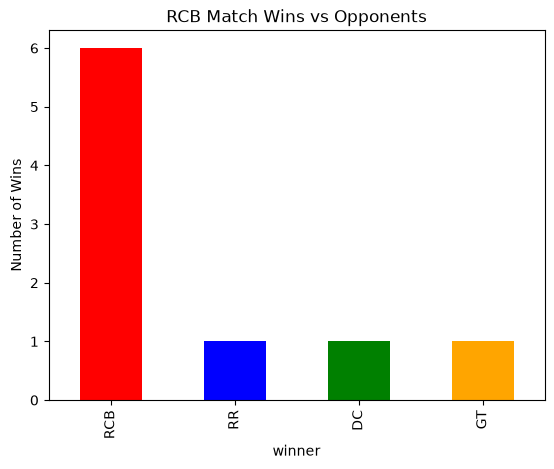

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot win distribution
win_counts.plot(kind='bar', color=['red', 'blue', 'green', 'orange'])
plt.title('RCB Match Wins vs Opponents')
plt.ylabel('Number of Wins')
plt.show()

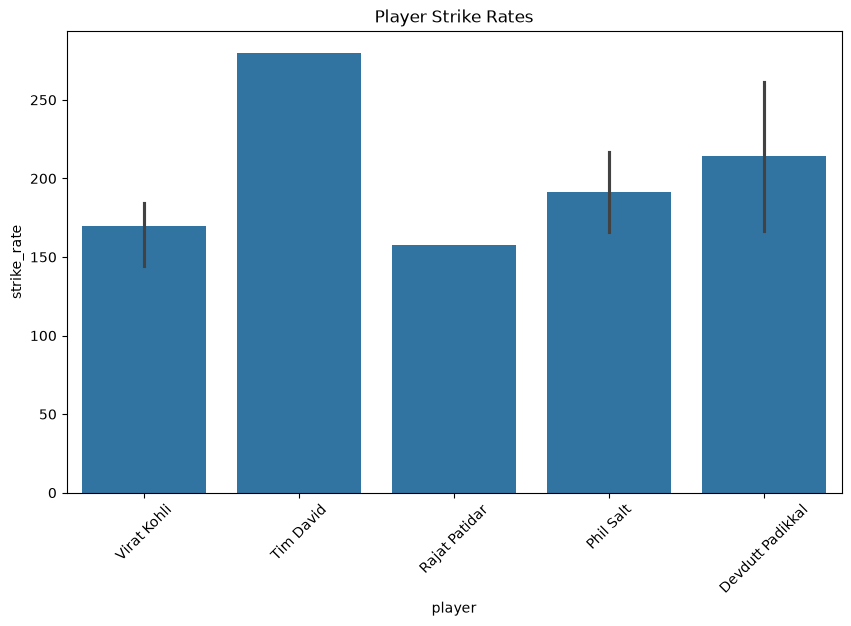

In [4]:
# Plot Strike Rate of Players
plt.figure(figsize=(10, 6))
sns.barplot(data=batting_df, x='player', y='strike_rate')
plt.title('Player Strike Rates')
plt.xticks(rotation=45)
plt.show()


In [5]:
# Group by player and get the mean of runs
avg_runs = batting_df.groupby('player')['runs'].mean()
print(avg_runs)


player
Devdutt Padikkal    37.000000
Phil Salt           70.500000
Rajat Patidar       63.000000
Tim David           70.000000
Virat Kohli         66.333333
Name: runs, dtype: float64


In [6]:
# Merge datasets to link player performance with match winners
analysis_df = pd.merge(batting_df, matches_df[['match_id', 'winner']], on='match_id')

# Check if RCB won when players scored big
rcb_wins = analysis_df[analysis_df['winner'] == 'RCB']
print(rcb_wins.groupby('player')['runs'].mean())

player
Devdutt Padikkal    34.000000
Phil Salt           78.000000
Tim David           70.000000
Virat Kohli         66.333333
Name: runs, dtype: float64
